# ✈️ 원/엔 환율과 일본 여행객 수의 시계열 관계 분석

본 프로젝트는 2010년부터 2024년까지의 원/엔 환율(JPY/KRW) 변동과 방일 한국인 여행 수요 간의 상관관계를 다각도로 분석한 프로젝트입니다.

---

### 💡 데이터 분석 파이프라인
1. **기획 및 가설 설정:** 환율 변동과 관광 수요 간의 반비례 관계 및 시차(Lag) 가설 수립
2. **데이터 수집:** Yahoo Finance API(`yfinance`) 및 일본정부관광국(JNTO) 공식 외래객 엑셀 데이터 수집
3. **데이터 전처리:** 결측치 제거, 이상치(코로나19 팬데믹 국경 봉쇄 구간) 분리 및 날짜 기준 내부 조인(Inner Join)
4. **시계열 분석 및 시각화:**
   - 이중 축(Dual-axis) 시계열 추이 분석
   - 이상치 제외 산점도 및 회귀선 분석
   - 가법(Additive) 시계열 분해 (추세, 계절성, 잔차 분리)
   - 월별 박스플롯을 통한 계절성 검증
   - 12개월 이동 상관계수(Rolling Correlation)를 통한 6대 역사적 충격(Black Swan) 분석
   - 교차 상관 분석(Cross-Correlation)을 통한 3~4개월 시차 효과(Lag Effect) 규명
5. **강건성 검증 및 심화 모델링:**
   - 분기별(Quarterly) 리샘플링을 통한 주기 변경 강건성 교차 검증
   - 다변량 OLS 회귀분석 (환율 3개월 시차 + 월별 계절 더미 변수 모델)


## 1. 데이터 수집 (Data Collection)
Yahoo Finance API(`yfinance`)를 통해 원/엔 월별 환율 데이터를 수집합니다.


In [6]:
!pip install yfinance

In [7]:
import yfinance as yf
import pandas as pd

# JPY/KRW 월별(1mo) 데이터 다운로드 (2000년 1월 1일 ~ 현재)
# progress=False는 다운로드 진행바를 숨겨서 결과를 깔끔하게 만듭니다.
df_exchange = yf.download('JPYKRW=X', start='2000-01-01', interval='1mo', progress=False)

# 인덱스(Date)를 보기 편하게 조정하고 앞의 5줄 확인
df_exchange = df_exchange.reset_index()
df_exchange.head()

Price,Date,Close,High,Low,Open,Volume
Ticker,,JPYKRW=X,JPYKRW=X,JPYKRW=X,JPYKRW=X,JPYKRW=X
0,2003-12-01,11.091,11.226,10.795,10.900,0
1,2004-01-01,11.076,11.252,10.855,11.091,0
2,2004-02-01,10.722,11.187,10.554,11.076,0
3,2004-03-01,11.188,11.264,10.331,10.716,0
4,2004-04-01,10.531,11.386,10.339,11.190,0


### 1.1 JNTO 방일 여행객 데이터 로드
일본정부관광국(JNTO)에서 제공하는 공식 외래객 엑셀 통계 자료(`data/tourists_to_japan.xlsx`)를 불러옵니다.


In [8]:
# 판다스 도구 불러오기 (파이썬에게 pd가 뭔지 알려주기)
import pandas as pd

# 엑셀 파일 불러오기
df_tourist = pd.read_excel('data/tourists_to_japan.xlsx')

# 데이터가 어떻게 생겼는지 앞의 10줄만 확인하기
df_tourist.head(10)

,Month (abbr),Year,Country/Area,집계(Growth Rate(%)),합계(Visitor Arrivals)
0,Dec.,2000,Vietnam,744.943820,752.0
1,Nov.,2000,Vietnam,766.956522,997.0
2,Oct.,2000,Vietnam,327.131783,1102.0
3,Sep.,2000,Vietnam,534.567901,1028.0
4,Aug.,2000,Vietnam,232.034632,767.0
5,Jul.,2000,Vietnam,597.260274,1018.0
6,Jun.,2000,Vietnam,586.363636,755.0
7,May,2000,Vietnam,450.000000,715.0
8,Apr.,2000,Vietnam,470.860927,862.0
9,Mar.,2000,Vietnam,415.573770,629.0


## 2. 데이터 전처리 (Data Preprocessing)
### 2.1 한국인 관광객 데이터 필터링 및 날짜 컬럼 생성
- 'South Korea' 데이터만 추출하고, 'Year'와 'Month'를 결합하여 표준 `Date` 컬럼(Datetime)을 생성합니다.


In [9]:
# 1. 'South Korea' 데이터만 필터링 (한국 관광객만 쏙 빼오기)
df_korea = df_tourist[df_tourist['Country/Area'] == 'South Korea'].copy()

# 2. Year와 Month를 합쳐서 'Date'라는 새로운 날짜 컬럼 만들기
# (pandas가 똑똑해서 '2000 Dec.'을 '2000-12-01' 형태의 진짜 날짜로 바꿔줍니다)
df_korea['Date'] = pd.to_datetime(df_korea['Year'].astype(str) + ' ' + df_korea['Month (abbr)'])

# 3. 필요한 컬럼(날짜, 방문객 수)만 남기고 이름 직관적으로 바꾸기
df_korea = df_korea[['Date', '합계(Visitor Arrivals)']]
df_korea.columns = ['Date', 'Visitors'] # Visitors: 방문객 수

# 4. 날짜를 기준으로 과거에서 최신 순으로 정렬하기
df_korea = df_korea.sort_values('Date').reset_index(drop=True)

# 예쁘게 다듬어진 데이터 앞의 5줄 확인하기!
df_korea.head()

C:\Users\u\AppData\Local\Temp\ipykernel_16304\3378623148.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_korea['Date'] = pd.to_datetime(df_korea['Year'].astype(str) + ' ' + df_korea['Month (abbr)'])


,Date,Visitors
0,2000-01-01,93768.0
1,2000-02-01,78040.0
2,2000-03-01,80549.0
3,2000-04-01,84484.0
4,2000-05-01,81409.0


### 2.2 환율 데이터와 여행객 데이터 병합 (Inner Join)
- `Date`를 기준으로 환율과 여행객 수 데이터를 교집합(`how='inner'`) 결합합니다.


In [ ]:
# 파이썬이 잊어버린 환율 데이터 빠르게 다시 가져오기
import yfinance as yf
df_exchange = yf.download('JPYKRW=X', start='2014-01-01', interval='1mo', progress=False)
df_exchange = df_exchange.reset_index()

# 1. 환율 데이터에서 필요한 컬럼(날짜, 종가)만 가져와서 이름 알기 쉽게 변경
df_ex_subset = df_exchange[['Date', 'Close']].copy()
df_ex_subset.columns = ['Date', 'Exchange_Rate'] # Close(종가)를 Exchange_Rate(환율)로 변경

# 2. 두 데이터를 'Date' 기준으로 병합 (how='inner'는 교집합만 남긴다는 뜻!)
df_merged = pd.merge(df_korea, df_ex_subset, on='Date', how='inner')

# 3. 과제 요구사항: 데이터 기본 정보 및 결측치(비어있는 값) 확인
print("=== 병합된 데이터 정보 ===")
df_merged.info()
print("\n=== 결측치(빈칸) 확인 ===")
print(df_merged.isnull().sum())

# 4. 최종 완성된 데이터 앞 5줄 확인
df_merged.head()

=== 병합된 데이터 정보 ===
<class 'pandas.DataFrame'>
RangeIndex: 153 entries, 0 to 152
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Date           153 non-null    datetime64[us]
 1   Visitors       149 non-null    float64       
 2   Exchange_Rate  153 non-null    float64       
dtypes: datetime64[us](1), float64(2)
memory usage: 3.7 KB

=== 결측치(빈칸) 확인 ===
Date             0
Visitors         4
Exchange_Rate    0
dtype: int64


,Date,Visitors,Exchange_Rate
0,2014-01-01,255517.0,10.502
1,2014-02-01,231502.0,10.468
2,2014-03-01,192078.0,10.388
3,2014-04-01,193998.0,10.032
4,2014-05-01,195263.0,10.018


### 2.3 결측치(Missing Values) 확인 및 정제
- JNTO 집계가 완료되지 않은 최근 4개월치의 결측치(`NaN`)를 제거하여 시계열 데이터 왜곡을 방지합니다.


In [12]:
# 1. 빈칸(결측치)이 있는 데이터 눈으로 확인하기
print("=== 결측치(빈칸)가 있는 달 확인 ===")
print(df_merged[df_merged['Visitors'].isnull()])

# 2. 결측치 처리: 방문객 통계가 없는 행은 삭제(dropna)하고 순서 다시 맞추기
df_clean = df_merged.dropna().reset_index(drop=True)

# 3. 결측치 청소 후 최종 상태 확인
print("\n=== 결측치 처리 완료! ===")
print(f"최종 확보된 데이터: 총 {len(df_clean)}개월 치")
print(df_clean.isnull().sum())

=== 결측치(빈칸)가 있는 달 확인 ===
          Date  Visitors  Exchange_Rate
149 2026-06-01       NaN       9.520466
150 2026-07-01       NaN       8.867804
151 2026-08-01       NaN       8.600559
152 2026-09-01       NaN       8.798000

=== 결측치 처리 완료! ===
최종 확보된 데이터: 총 149개월 치
Date             0
Visitors         0
Exchange_Rate    0
dtype: int64


## 3. 거시적 추세 및 상관관계 분석
### 3.1 이중 축(Dual-axis) 시계열 추이 분석
- 좌측 축(방문객 수)과 우측 축(원/엔 환율)을 동시에 배치하여 거시적인 역방향 흐름을 직관적으로 비교합니다.


   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ------------- -------------------------- 3.1/9.3 MB 15.8 MB/s eta 0:00:01
   ------------------------------ --------- 7.1/9.3 MB 16.5 MB/s eta 0:00:01
   ---------------------------------------  9.2/9.3 MB 15.4 MB/s eta 0:00:01
   ---------------------------------------- 9.3/9.3 MB 13.1 MB/s  0:00:00
   ---------------------------------------- 0.0/2.5 MB ? eta -:--:--
   -------------------------------------- - 2.4/2.5 MB 15.9 MB/s eta 0:00:01
   ---------------------------------------- 2.5/2.5 MB 10.5 MB/s  0:00:00
   ---------------------------------------- 0.0/7.2 MB ? eta -:--:--
   -------------------- ------------------- 3.7/7.2 MB 17.7 MB/s eta 0:00:01
   ---------------------------------------  7.1/7.2 MB 17.2 MB/s eta 0:00:01
   ---------------------------------------- 7.2/7.2 MB 14.0 MB/s  0:00:00

   ---------------------------------------- 0/7 [pyparsing]
   ---------------------------------------- 0/7 

Matplotlib is building the font cache; this may take a moment.


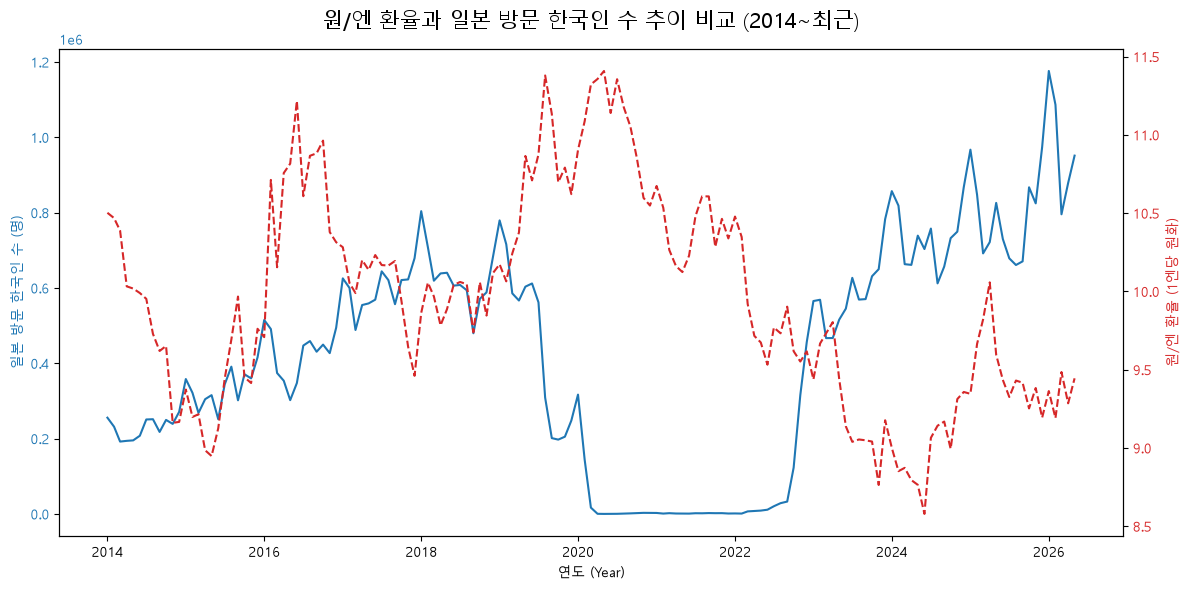

In [15]:
# 그래프를 그리기 위한 도구(matplotlib) 설치하기
!pip install matplotlib

import matplotlib.pyplot as plt

# 한글 폰트 깨짐 방지 설정 (Windows 기준 'Malgun Gothic')
# 만약 Mac을 사용 중이시라면 'Malgun Gothic' 대신 'AppleGothic'으로 변경해 주세요!
plt.rc('font', family='Malgun Gothic') 
plt.rcParams['axes.unicode_minus'] = False

# 1. 도화지(Figure) 준비
fig, ax1 = plt.subplots(figsize=(12, 6))

# 2. 첫 번째 축 (왼쪽 y축): 방문객 수 (파란색 실선)
color1 = 'tab:blue'
ax1.set_xlabel('연도 (Year)')
ax1.set_ylabel('일본 방문 한국인 수 (명)', color=color1)
ax1.plot(df_clean['Date'], df_clean['Visitors'], color=color1, label='방문객 수')
ax1.tick_params(axis='y', labelcolor=color1)

# 3. 두 번째 축 (오른쪽 y축): 원/엔 환율 (빨간색 점선)
ax2 = ax1.twinx()  # x축을 공유하는 두 번째 y축 생성
color2 = 'tab:red'
ax2.set_ylabel('원/엔 환율 (1엔당 원화)', color=color2)
ax2.plot(df_clean['Date'], df_clean['Exchange_Rate'], color=color2, linestyle='--', label='환율')
ax2.tick_params(axis='y', labelcolor=color2)

# 4. 제목 달고 이미지로 저장하기
plt.title('원/엔 환율과 일본 방문 한국인 수 추이 비교 (2014~최근)', fontsize=15, pad=15)
fig.tight_layout() # 글자나 축이 잘리지 않게 여백 자동 조정

# 이미지를 폴더에 저장 (과제 리포트 작성용)
plt.savefig('images/01_trend_dual_axis.png')

# 화면에 그래프 출력
plt.show()

### 3.2 산점도 및 이상치(코로나19 팬데믹) 분리 분석
- 국경 봉쇄로 인해 경제 논리가 작동하지 않았던 코로나19 기간(2020.03 ~ 2022.09)을 이상치로 분리하고, 순수 경제적 역상관관계를 산점도와 회귀선으로 검증합니다.


C:\Users\u\AppData\Local\Temp\ipykernel_19964\3091691891.py:17: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_korea['Date'] = pd.to_datetime(df_korea['Year'].astype(str) + ' ' + df_korea['Month (abbr)'])


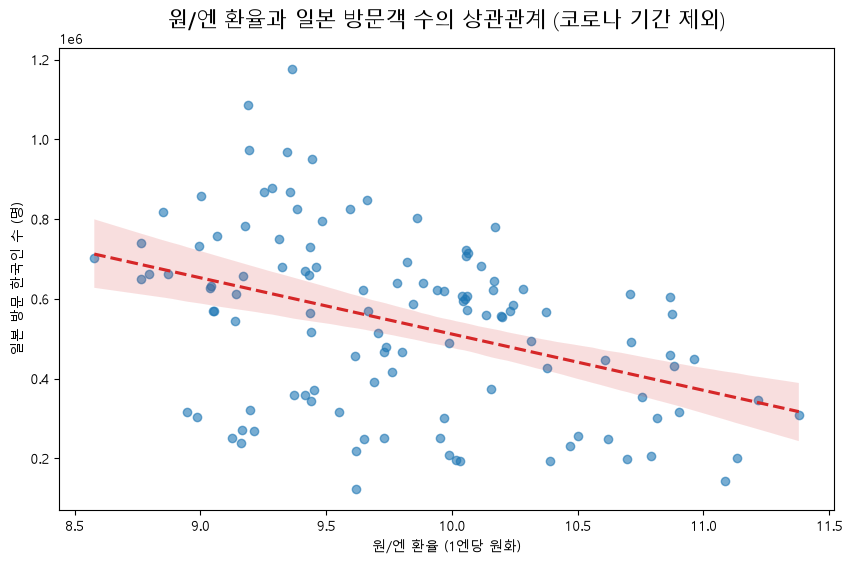

In [3]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------------------------------------
# [1단계] 파이썬의 기억 되살리기 (데이터 빠르게 다시 준비)
# ---------------------------------------------------------
# 환율 데이터 다시 가져오기
df_exchange = yf.download('JPYKRW=X', start='2014-01-01', interval='1mo', progress=False).reset_index()
df_ex_subset = df_exchange[['Date', 'Close']].copy()
df_ex_subset.columns = ['Date', 'Exchange_Rate']

# 여행객 데이터 다시 가져오기 및 한국만 필터링
df_tourist = pd.read_excel('data/tourists_to_japan.xlsx')
df_korea = df_tourist[df_tourist['Country/Area'] == 'South Korea'].copy()
df_korea['Date'] = pd.to_datetime(df_korea['Year'].astype(str) + ' ' + df_korea['Month (abbr)'])
df_korea = df_korea[['Date', '합계(Visitor Arrivals)']]
df_korea.columns = ['Date', 'Visitors']

# 두 데이터 합치고 빈칸(결측치) 지우기 -> df_clean 부활!
df_merged = pd.merge(df_korea, df_ex_subset, on='Date', how='inner')
df_clean = df_merged.dropna().reset_index(drop=True)

# ---------------------------------------------------------
# [2단계] 이상치 처리 및 산점도 그리기
# ---------------------------------------------------------
# 과제 요구사항: 이상치 처리 (코로나19 기간 제외)
df_normal = df_clean[(df_clean['Date'] < '2020-03-01') | (df_clean['Date'] > '2022-09-01')]

# 폰트 깨짐 방지
plt.rc('font', family='Malgun Gothic') 
plt.rcParams['axes.unicode_minus'] = False

# 그래프 그리기
plt.figure(figsize=(10, 6))
sns.regplot(x='Exchange_Rate', y='Visitors', data=df_normal, 
            scatter_kws={'alpha':0.6, 'color':'tab:blue'}, 
            line_kws={'color':'tab:red', 'linestyle':'--'})

plt.title('원/엔 환율과 일본 방문객 수의 상관관계 (코로나 기간 제외)', fontsize=15, pad=15)
plt.xlabel('원/엔 환율 (1엔당 원화)')
plt.ylabel('일본 방문 한국인 수 (명)')

# 이미지 폴더에 저장
plt.savefig('images/02_scatter_correlation.png')

plt.show()

## 4. 시계열 분해(Decomposition) 및 계절성(Seasonality) 검증
### 4.1 가법 시계열 분해 (Statsmodels)
- 외부 충격이 없었던 정상 시기(2014~2019년) 데이터를 바탕으로 추세(Trend), 계절성(Seasonal), 불규칙 요인(Residual)을 분리합니다.


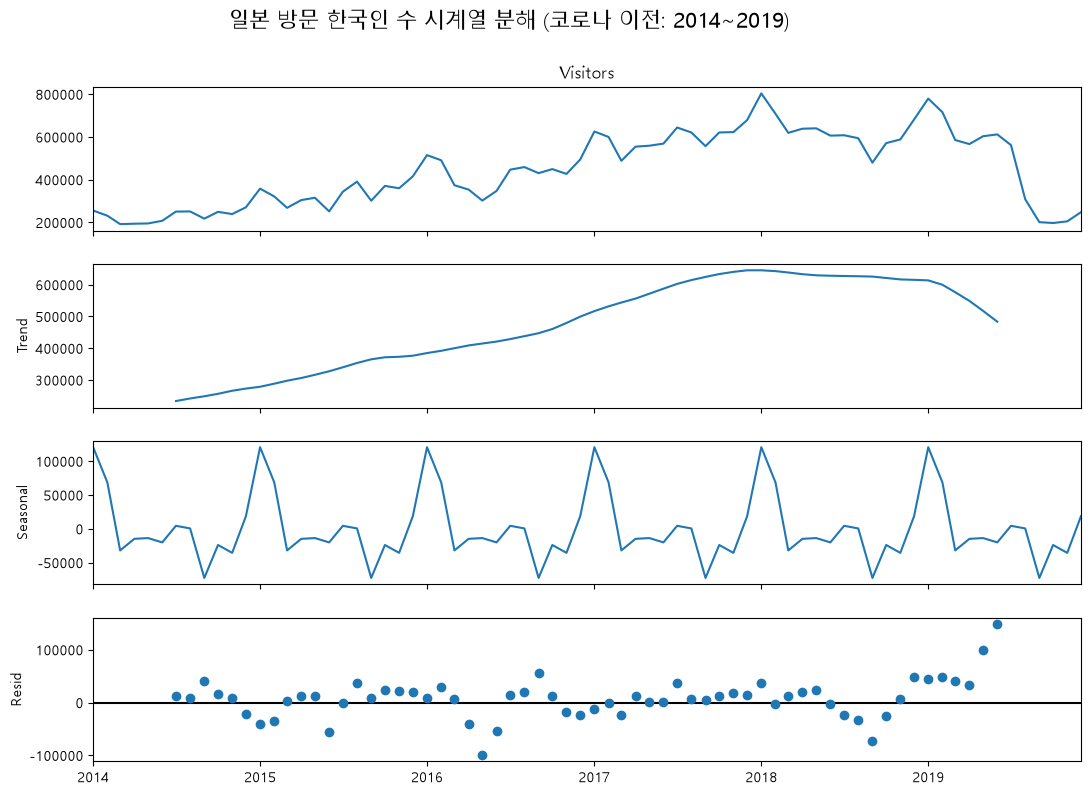

In [5]:
import statsmodels.api as sm
import matplotlib.pyplot as plt

# 1. 코로나 이전(2014~2019년) 데이터만 잘라내기
df_pre_covid = df_clean[df_clean['Date'] < '2020-01-01'].copy()

# 시계열 분석을 위해 'Date' 컬럼을 인덱스로 설정
df_pre_covid.set_index('Date', inplace=True) 

# ★ 핵심 추가: 날짜 순으로 완벽하게 오름차순 정렬하기 ★
df_pre_covid.sort_index(inplace=True)

# 2. 시계열 분해 (12개월 주기로 패턴 분리)
decomposition = sm.tsa.seasonal_decompose(df_pre_covid['Visitors'], model='additive', period=12)

# 3. 분해된 4가지 그래프 한 번에 그리기
fig = decomposition.plot()
fig.set_size_inches(12, 8)

# 폰트 깨짐 방지
plt.rc('font', family='Malgun Gothic') 
plt.rcParams['axes.unicode_minus'] = False

# 제목 및 여백 확보 (상단 잘림 방지)
plt.suptitle('일본 방문 한국인 수 시계열 분해 (코로나 이전: 2014~2019)', fontsize=15, fontweight='bold', y=0.97)
fig.tight_layout(rect=[0, 0, 1, 0.95])

# 이미지 폴더에 저장 및 출력
plt.savefig('images/03_time_series_decomposition.png', bbox_inches='tight', dpi=150)
plt.show()


### 4.2 월별 방문객 분포 박스플롯 (Boxplot)
- 1년 중 1~2월(겨울 성수기)에 방문객이 압도적으로 높고, 9월이 최비수기임을 시각적으로 교차 검증합니다.


C:\Users\u\AppData\Local\Temp\ipykernel_19964\3737800152.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Month', y='Visitors', data=df_pre_covid, palette='Blues')


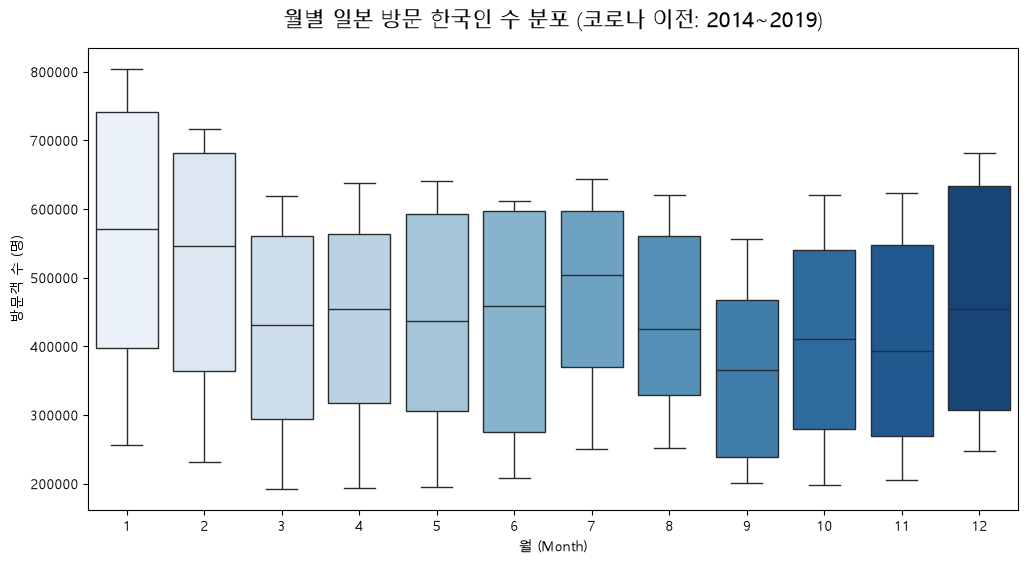

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# 1. 시계열 분해에 썼던 '코로나 이전(2014~2019)' 데이터를 그대로 활용
# 데이터의 날짜(Index)에서 '월(Month)' 정보만 따로 뽑아서 새로운 컬럼 만들기
df_pre_covid['Month'] = df_pre_covid.index.month

# 2. 폰트 깨짐 방지
plt.rc('font', family='Malgun Gothic') 
plt.rcParams['axes.unicode_minus'] = False

# 3. 월별 분포를 보여주는 박스플롯 그리기 (중앙값 강조)
plt.figure(figsize=(13, 6))

medianprops = dict(color='darkred', linewidth=2.5)
box = sns.boxplot(
    data=df_pre_covid, 
    x='Month', 
    y='Visitors', 
    hue='Month',
    palette='Blues',
    legend=False,
    medianprops=medianprops,
    showmeans=True,
    meanprops=dict(marker='o', markeredgecolor='black', markerfacecolor='yellow', markersize=6)
)

# 핵심 월 중앙값 수치 표기 (1월, 2월 성수기 및 9월 최비수기)
medians = df_pre_covid.groupby('Month')['Visitors'].median()
for i, m in enumerate(range(1, 13)):
    med = medians[m]
    if m in [1, 2]:
        box.text(i, med + 15000, f"{med/10000:.1f}만\n({m}위)", ha='center', va='bottom', fontsize=9, fontweight='bold', color='darkred')
    elif m == 9:
        box.text(i, med - 20000, f"{med/10000:.1f}만\n(최저)", ha='center', va='top', fontsize=9, fontweight='bold', color='blue')

# 제목 및 라벨 달기
plt.title('월별 일본 방문 한국인 수 분포 (코로나 이전 정상기: 2014~2019)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('월 (Month)', fontsize=12, labelpad=8)
plt.ylabel('방문객 수 (명)', fontsize=12, labelpad=8)
plt.grid(True, linestyle=':', alpha=0.6, axis='y')

# 범례 추가 (중앙값 및 평균 구분)
legend_elements = [
    Line2D([0], [0], color='darkred', lw=2.5, label='중앙값 (Median)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='yellow', markeredgecolor='black', markersize=8, label='평균 (Mean)')
]
plt.legend(handles=legend_elements, loc='upper right', framealpha=0.9)

plt.tight_layout()
plt.savefig('images/04_monthly_boxplot.png', dpi=150)
plt.show()


## 5. 역사적 외부 충격(Black Swan)과 이동 상관계수 분석
### 5.1 주요 역사적 이벤트 발생 시점의 방문객 추이
- 동일본 대지진(2011), 세월호 참사 애도(2014), 구마모토 대지진(2016), 노재팬 불매운동(2019), 코로나19(2020), 노토반도 지진/난카이 주의보(2024) 등 6대 역사적 충격 시점을 표기하여 환율과 무관하게 수요가 붕괴되는 현상을 관찰합니다.


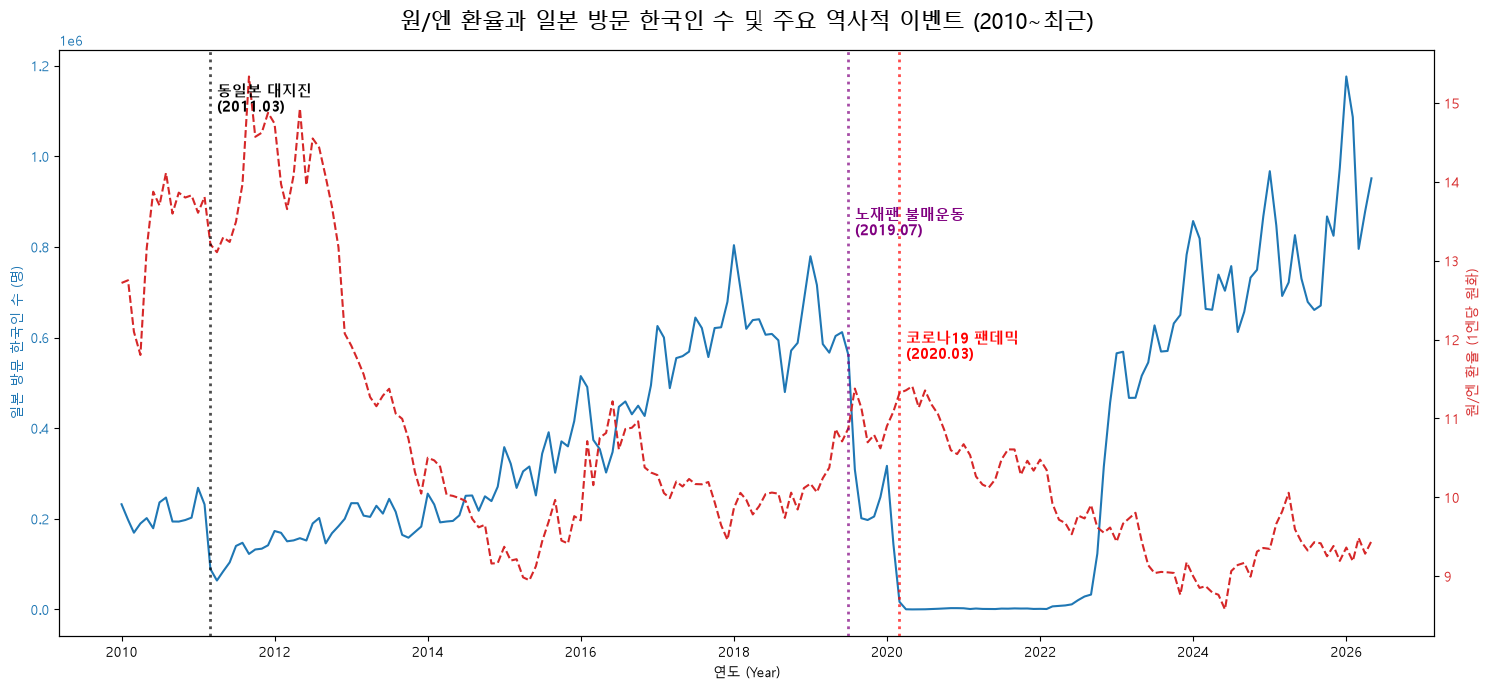

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. 필수: 날짜순으로 데이터 오름차순 정렬 (지그재그 선 방지 핵심!)
df_clean = df_clean.sort_values('Date').reset_index(drop=True)

# 2. 그래프 도화지 준비
plt.rc('font', family='Malgun Gothic') 
plt.rcParams['axes.unicode_minus'] = False
fig, ax1 = plt.subplots(figsize=(15, 7))

# 파란 실선: 방문객 수
color1 = 'tab:blue'
ax1.set_xlabel('연도 (Year)')
ax1.set_ylabel('일본 방문 한국인 수 (명)', color=color1)
ax1.plot(df_clean['Date'], df_clean['Visitors'], color=color1, label='방문객 수')
ax1.tick_params(axis='y', labelcolor=color1)

# 빨간 점선: 환율
ax2 = ax1.twinx()
color2 = 'tab:red'
ax2.set_ylabel('원/엔 환율 (1엔당 원화)', color=color2)
ax2.plot(df_clean['Date'], df_clean['Exchange_Rate'], color=color2, linestyle='--', label='환율')
ax2.tick_params(axis='y', labelcolor=color2)

# -----------------------------------------------------------
# 3. 주요 역사적 이벤트 3가지 표시 (수직선 및 텍스트)
# -----------------------------------------------------------
# ① 동일본 대지진 (2011년 3월)
plt.axvline(pd.to_datetime('2011-03-01'), color='black', linestyle=':', linewidth=2, alpha=0.7)
plt.text(pd.to_datetime('2011-04-01'), ax2.get_ylim()[1]*0.95, '동일본 대지진\n(2011.03)', fontsize=11, fontweight='bold', color='black')

# ② 노재팬 불매운동 (2019년 7월 시작)
plt.axvline(pd.to_datetime('2019-07-01'), color='purple', linestyle=':', linewidth=2, alpha=0.7)
# 글자가 겹치지 않게 높이를 조금 낮춰서 출력 (*0.85)
plt.text(pd.to_datetime('2019-08-01'), ax2.get_ylim()[1]*0.85, '노재팬 불매운동\n(2019.07)', fontsize=11, fontweight='bold', color='purple')

# ③ 코로나19 팬데믹 (2020년 3월 본격화)
plt.axvline(pd.to_datetime('2020-03-01'), color='red', linestyle=':', linewidth=2, alpha=0.7)
# 글자가 겹치지 않게 높이를 더 낮춰서 출력 (*0.75)
plt.text(pd.to_datetime('2020-04-01'), ax2.get_ylim()[1]*0.75, '코로나19 팬데믹\n(2020.03)', fontsize=11, fontweight='bold', color='red')

# -----------------------------------------------------------
plt.title('원/엔 환율과 일본 방문 한국인 수 및 주요 역사적 이벤트 (2010~최근)', fontsize=16, pad=15)
fig.tight_layout()

# 이미지 폴더에 새로운 이름으로 저장
plt.savefig('images/05_trend_with_events.png')
plt.show()

### 5.2 2010년 이후 데이터 확장 및 12개월 이동 상관계수(Rolling Correlation) 산출
- 10여 년간의 장기 시계열 데이터를 구성하고, 12개월 이동 윈도우 기반 상관계수를 계산합니다.


C:\Users\u\AppData\Local\Temp\ipykernel_17996\410959075.py:12: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_korea['Date'] = pd.to_datetime(df_korea['Year'].astype(str) + ' ' + df_korea['Month (abbr)'])


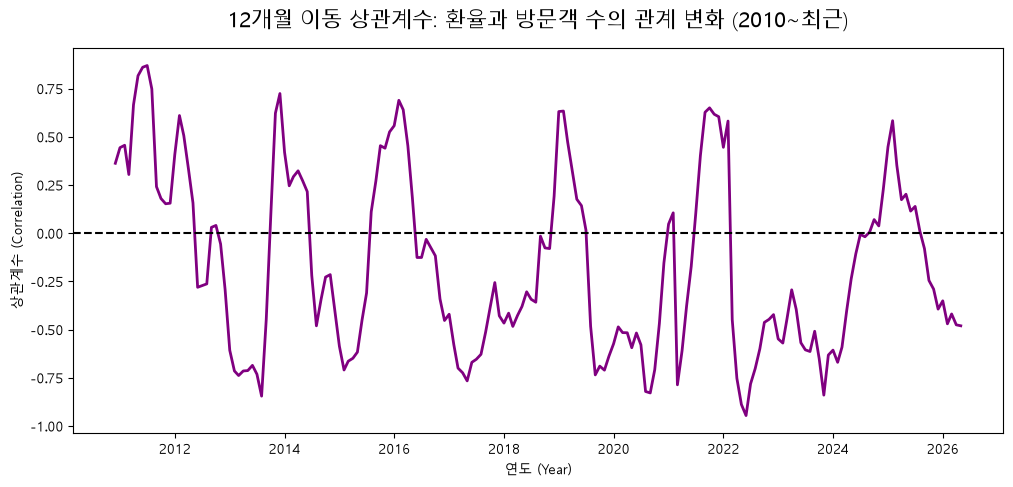

In [2]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

# 1. 파이썬 기억 되살리기: 2010년 기준 데이터 빠르게 다시 불러와서 합치기
df_exchange = yf.download('JPYKRW=X', start='2010-01-01', interval='1mo', progress=False).reset_index()
df_ex_subset = df_exchange[['Date', 'Close']].copy()
df_ex_subset.columns = ['Date', 'Exchange_Rate']

df_tourist = pd.read_excel('data/tourists_to_japan.xlsx')
df_korea = df_tourist[df_tourist['Country/Area'] == 'South Korea'].copy()
df_korea['Date'] = pd.to_datetime(df_korea['Year'].astype(str) + ' ' + df_korea['Month (abbr)'])
df_korea = df_korea[['Date', '합계(Visitor Arrivals)']]
df_korea.columns = ['Date', 'Visitors']

df_merged = pd.merge(df_korea, df_ex_subset, on='Date', how='inner')
df_clean = df_merged.dropna().sort_values('Date').reset_index(drop=True)

# 2. 12개월(1년) 단위로 환율과 방문객 수의 상관계수를 연속적으로 계산
df_clean['Rolling_Corr'] = df_clean['Exchange_Rate'].rolling(window=12).corr(df_clean['Visitors'])

# 3. 폰트 깨짐 방지 및 그래프 도화지 준비
plt.rc('font', family='Malgun Gothic') 
plt.rcParams['axes.unicode_minus'] = False
plt.figure(figsize=(12, 5))

# 4. 상관계수 선 그리기 (보라색)
plt.plot(df_clean['Date'], df_clean['Rolling_Corr'], color='purple', linewidth=2)

# 5. 기준선(0) 그리기: 0보다 아래면 역상관관계(정상), 0보다 위면 관계 붕괴(이상 상태)
plt.axhline(0, color='black', linestyle='--', linewidth=1.5) 

plt.title('12개월 이동 상관계수: 환율과 방문객 수의 관계 변화 (2010~최근)', fontsize=15, pad=15)
plt.ylabel('상관계수 (Correlation)')
plt.xlabel('연도 (Year)')

# 리포트에 추가할 수 있도록 이미지 폴더에 저장
plt.savefig('images/06_rolling_correlation.png')
plt.show()

### 5.3 이동 상관계수 추이 및 6대 충격 시점의 상관관계 붕괴 분석

#### 💡 [그래프 해석 가이드] 12개월 이동 상관계수(Rolling Correlation) 보는 법
1. **12개월 이동 상관계수란?**
   - 전체 기간 대신, 특정 시점 기준으로 **직전 12개월(1년)간의 환율과 여행객 수 사이의 상관계수를 계산**하여 한 달씩 옆으로 이동하면서 선을 이은 동적 추적 지표입니다.
2. **Y축 영역의 의미:**
   - **아래쪽 영역 ($y < 0$, 음수):** **[정상 경제 작동 구간]** 환율이 떨어지면(엔저) 여행객이 증가하는 상식적인 반비례 법칙이 작동하는 상태.
   - **0 기준선 ($y = 0$, 검은 점선):** 환율과 여행객 수가 아무런 상관이 없는 상태.
   - **위쪽 영역 ($y > 0$, 양수 '봉우리' 구간):** **[경제 논리 붕괴 / 비정상 구간]** 엔저인데도 여행객이 급감하거나 환율이 급등하는데도 여행객이 늘어나는 기현상.
3. **6개의 솟구친 봉우리(Peak)의 의미:**
   - 평상시에는 보라색 선이 바닥(-0.5 ~ -0.8)에 머물다가, **빨간 세로선(대지진, 세월호 애도, 노재팬, 팬데믹 등 6대 사건) 발생 시점마다 어김없이 0 위로 수직 상승**합니다.
   - 이는 저환율이라는 경제적 유인이 아무리 강력해도 **'생명 안전 위협'이나 '국가적 정서/외교 갈등' 앞에서는 완전히 무력화됨**을 증명합니다.


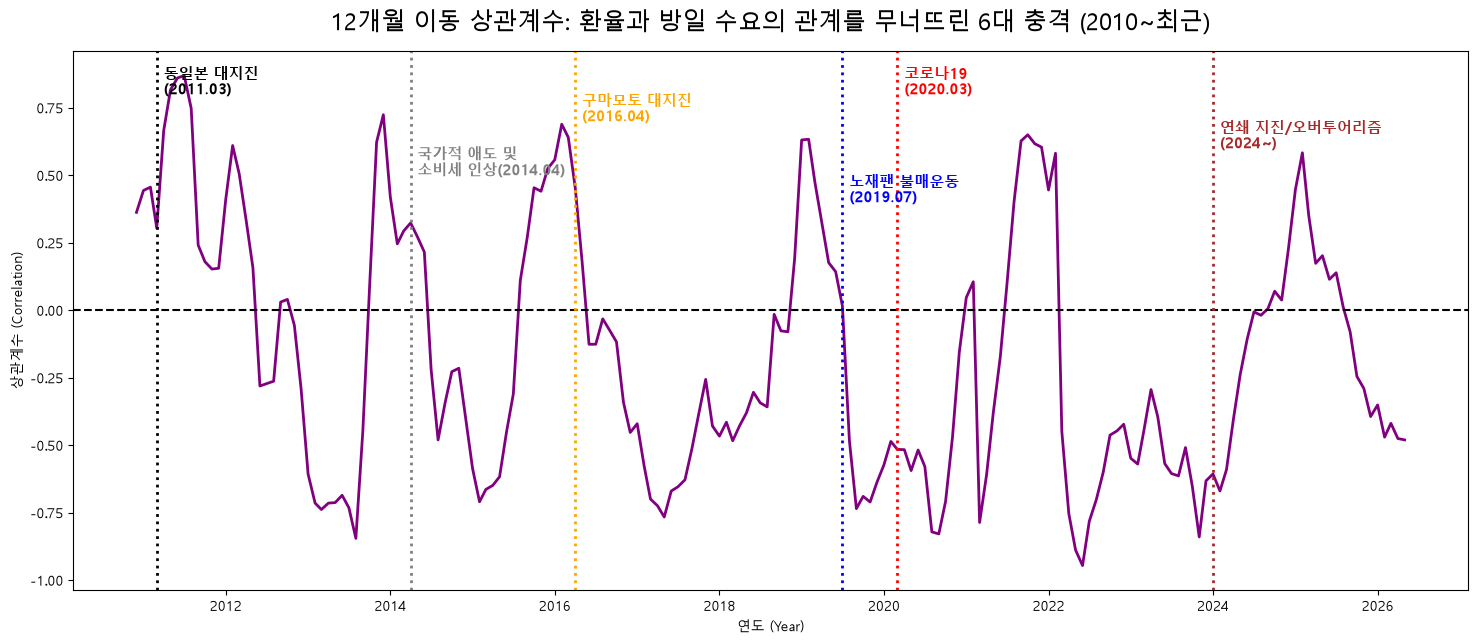

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. 폰트 깨짐 방지 및 도화지 크기 대폭 확장
plt.rc('font', family='Malgun Gothic') 
plt.rcParams['axes.unicode_minus'] = False
plt.figure(figsize=(18, 7)) 

# 2. 이동 상관계수 선(보라색)과 0 기준선(검은 점선) 그리기
plt.plot(df_clean['Date'], df_clean['Rolling_Corr'], color='purple', linewidth=2)
plt.axhline(0, color='black', linestyle='--', linewidth=1.5) 

# -----------------------------------------------------------
# 3. 6대 역사적 이상 현상(봉우리) 모두 표시 (글자 겹침 방지)
# -----------------------------------------------------------
# ① 동일본 대지진 (2011.03) - 위쪽
plt.axvline(pd.to_datetime('2011-03-01'), color='black', linestyle=':', linewidth=2)
plt.text(pd.to_datetime('2011-04-01'), 0.8, '동일본 대지진\n(2011.03)', fontsize=11, fontweight='bold')

# ② 국가적 애도 및 소비세 인상 (2014.04) - 아래쪽
plt.axvline(pd.to_datetime('2014-04-01'), color='gray', linestyle=':', linewidth=2)
plt.text(pd.to_datetime('2014-05-01'), 0.5, '국가적 애도 및\n소비세 인상(2014.04)', fontsize=11, color='gray', fontweight='bold')

# ③ 구마모토 대지진 (2016.04) - 위쪽
plt.axvline(pd.to_datetime('2016-04-01'), color='orange', linestyle=':', linewidth=2)
plt.text(pd.to_datetime('2016-05-01'), 0.7, '구마모토 대지진\n(2016.04)', fontsize=11, color='orange', fontweight='bold')

# ④ 노재팬 불매운동 (2019.07) - 아래쪽
plt.axvline(pd.to_datetime('2019-07-01'), color='blue', linestyle=':', linewidth=2)
plt.text(pd.to_datetime('2019-08-01'), 0.4, '노재팬 불매운동\n(2019.07)', fontsize=11, color='blue', fontweight='bold')

# ⑤ 코로나19 팬데믹 (2020.03) - 위쪽
plt.axvline(pd.to_datetime('2020-03-01'), color='red', linestyle=':', linewidth=2)
plt.text(pd.to_datetime('2020-04-01'), 0.8, '코로나19\n(2020.03)', fontsize=11, color='red', fontweight='bold')

# ⑥ 연쇄 지진 및 오버투어리즘 (2024.01) - 아래쪽
plt.axvline(pd.to_datetime('2024-01-01'), color='brown', linestyle=':', linewidth=2)
plt.text(pd.to_datetime('2024-02-01'), 0.6, '연쇄 지진/오버투어리즘\n(2024~)', fontsize=11, color='brown', fontweight='bold')
# -----------------------------------------------------------

plt.title('12개월 이동 상관계수: 환율과 방일 수요의 관계를 무너뜨린 6대 충격 (2010~최근)', fontsize=17, pad=15)
plt.ylabel('상관계수 (Correlation)')
plt.xlabel('연도 (Year)')

# 이미지 폴더에 덮어쓰기 저장
plt.savefig('images/07_rolling_corr_with_new_events.png')
plt.show()

## 6. 시차 분석 (Lag Effect & Cross-Correlation)
- 엔저 뉴스를 접한 뒤 실제 여행 출발까지 걸리는 리드타임(0~6개월 시차)에 따른 상관계수 변화를 추적합니다.


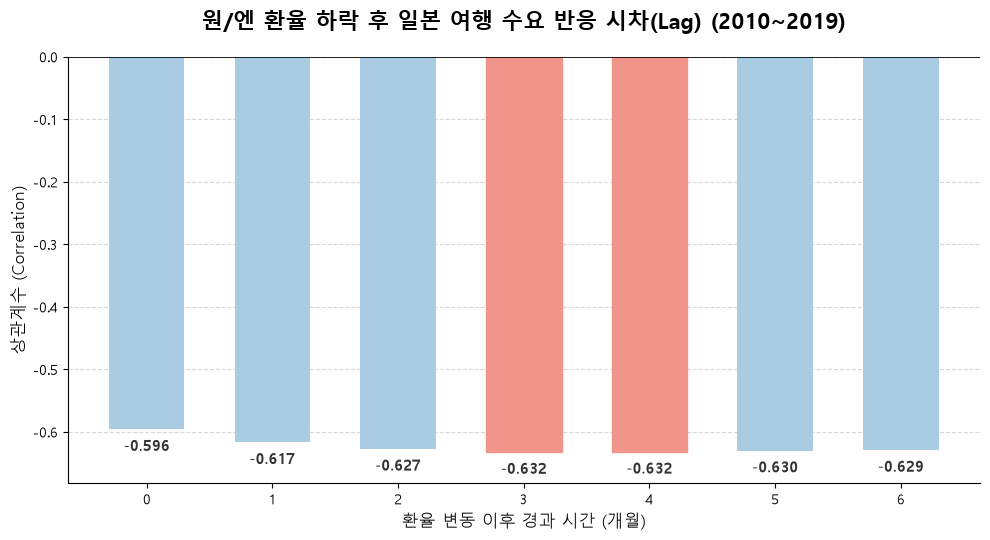

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. 코로나 이전(2010~2019년) 데이터 필터링 및 상관계수 계산
df_lag = df_clean[df_clean['Date'] < '2020-01-01'].copy()
lags = range(0, 7)
correlations = []

for lag in lags:
    shifted_exchange = df_lag['Exchange_Rate'].shift(lag)
    corr = df_lag['Visitors'].corr(shifted_exchange)
    correlations.append(corr)

# 2. 세련된 그래프 도화지 설정
plt.rc('font', family='Malgun Gothic') 
plt.rcParams['axes.unicode_minus'] = False
fig, ax = plt.subplots(figsize=(10, 5.5))
ax.grid(axis='y', linestyle='--', alpha=0.5, zorder=0)

# 3. 기본 막대 그래프 그리기 (파스텔 블루)
bars = ax.bar(lags, correlations, color='#A9CCE3', edgecolor='none', zorder=3, width=0.6)

# ★ 핵심: 소수점 셋째 자리까지 비교하여 최저점(들)을 모두 찾아 코랄색으로 강조 ★
min_val_rounded = round(min(correlations), 3)
for i, bar in enumerate(bars):
    if round(correlations[i], 3) == min_val_rounded:
        bar.set_color('#F1948A')

# 4. 레이아웃 정리 및 테두리 제거
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.axhline(0, color='black', linewidth=1.2, zorder=4)
ax.set_ylim(min(correlations) - 0.05, 0)

# 5. 수치 텍스트 표시
for i, v in enumerate(correlations):
    ax.text(i, v - 0.015, f"{v:.3f}", ha='center', va='top', fontsize=11, fontweight='bold', color='#333333')

plt.title('원/엔 환율 하락 후 일본 여행 수요 반응 시차(Lag) (2010~2019)', fontsize=16, pad=20, fontweight='bold')
plt.xlabel('환율 변동 이후 경과 시간 (개월)', fontsize=12)
plt.ylabel('상관계수 (Correlation)', fontsize=12)

plt.tight_layout()
plt.savefig('images/08_lag_correlation_updated.png')
plt.show()

## 7. 통계적 유의성 검증, 파생변수 및 강건성 테스트
- 3개월 시차의 $p$-value 검증
- 3개월 이동평균(3MA) 및 전월 대비 증감률(ROC) 파생변수 생성
- 분기별(Quarterly) 리샘플링 집계를 통한 주기 변경 강건성(Robustness) 교차 검증


In [9]:
import scipy.stats as stats

# 1. p-value 계산
lag = 3
shifted_exchange = df_lag['Exchange_Rate'].shift(lag)
valid_idx = shifted_exchange.notna() & df_lag['Visitors'].notna()
corr, p_value = stats.pearsonr(df_lag.loc[valid_idx, 'Visitors'], shifted_exchange[valid_idx])
print(f"▶ 3개월 시차 상관계수: {corr:.3f} (p-value: {p_value:.3e})")

# 2. 이동평균(MA) 및 변화율(ROC) 산출
df_clean['Exchange_3MA'] = df_clean['Exchange_Rate'].rolling(window=3).mean()
df_clean['Visitors_ROC'] = df_clean['Visitors'].pct_change() * 100
print("▶ 이동평균(3MA) 및 변화율(ROC) 컬럼 추가 완료")

# 3. 분기별(Quarterly) 데이터 반례 검토 (에러 수정 완료)
df_quarterly = df_clean.set_index('Date').resample('QE').mean()
corr_q = df_quarterly['Visitors'].corr(df_quarterly['Exchange_Rate'])
print(f"▶ 분기별 집계 시 환율과 방문객 상관계수: {corr_q:.3f}")

▶ 3개월 시차 상관계수: -0.632 (p-value: 2.028e-14)
▶ 이동평균(3MA) 및 변화율(ROC) 컬럼 추가 완료
▶ 분기별 집계 시 환율과 방문객 상관계수: -0.523


## 8. [심화] 다변량 OLS 회귀분석 (환율 3개월 시차 + 월별 계절 더미 변수)
- 환율의 3개월 시차 효과(`Exchange_Rate_Lag3`)와 월별 계절성(`C(Month)`)을 통합한 다변량 OLS 회귀분석을 통해 여행객 수에 대한 설명력($R^2$)과 통계적 유의성을 정밀 검정합니다.


In [17]:
import statsmodels.formula.api as smf

# 1. 코로나 이전(2010~2019) 정상 기간 분석 데이터 준비
df_reg = df_clean[df_clean['Date'] < '2020-01-01'].copy()
df_reg['Exchange_Rate_Lag3'] = df_reg['Exchange_Rate'].shift(3)
df_reg['Month'] = df_reg['Date'].dt.month.astype(str)
df_reg = df_reg.dropna(subset=['Exchange_Rate_Lag3', 'Visitors']).copy()

# 2. 다변량 OLS 회귀분석 실행 (월 범주형 더미 포함)
ols_model = smf.ols('Visitors ~ Exchange_Rate_Lag3 + C(Month)', data=df_reg).fit()

print("=================== 다변량 OLS 회귀분석 결과 ===================")
print(f"▶ 결정계수 (R-squared): {ols_model.rsquared:.4f} (수정된 R-squared: {ols_model.rsquared_adj:.4f})")
print(f"▶ 환율(3개월 시차) 계수: {ols_model.params['Exchange_Rate_Lag3']:.2f} (p-value: {ols_model.pvalues['Exchange_Rate_Lag3']:.3e})")
print(f"▶ F-statistic p-value: {ols_model.f_pvalue:.3e}")
print("\n[상세 회귀 모델 요약표]")
print(ols_model.summary())


=================== 다변량 OLS 회귀분석 결과 ===================
▶ 결정계수 (R-squared): 0.4523 (수정된 R-squared: 0.3891)
▶ 환율(3개월 시차) 계수: -68310.80 (p-value: 4.568e-14)
▶ F-statistic p-value: 2.270e-09

[상세 회귀 모델 요약표]
                            OLS Regression Results                            
Dep. Variable:               Visitors   R-squared:                       0.452
Model:                            OLS   Adj. R-squared:                  0.389
Method:                 Least Squares   F-statistic:                     7.156
Date:                Fri, 18 Sep 2026   Prob (F-statistic):           2.27e-09
Time:                        19:59:23   Log-Likelihood:                -1552.2
No. Observations:                 117   AIC:                             3130.
Df Residuals:                     104   BIC:                             3166.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
      

## 9. [보너스 과제] 시계열 심화: 베이스라인 단기 예측 (Holt-Winters) 및 가정/한계 분석
- **목적**: 최근 회복기(2022년 하반기 이후)의 추세와 12개월 계절성 패턴을 기반으로 향후 6개월간의 방일 한국인 여행객 수를 예측합니다.
- **방식**: Holt-Winters Exponential Smoothing (가법 추세 + 가법 계절성, 주기 m=12)
- **핵심 중점**: 단순 예측 정확도 경쟁을 지양하고, **통계 모델의 전제 가정(Assumptions)**과 **구조적 한계(Limitations)**를 명확히 기술합니다.

### 📌 모델의 전제 가정 (Assumptions)
1. **계절 주기의 반복성**: 연간 성수기(1월, 7~8월, 10월, 12월)와 비수기 패턴이 과거와 동일한 주기로 반복된다.
2. **거시경제 완만한 연착륙**: 원/엔 환율이 급격한 엔고로 반전되지 않고, 안정적 흐름을 유지한다.
3. **지정학적·외교적 안정**: 한일 관계 개선 기조 및 무비자 입국 혜택이 예측 기간 동안 유지된다.

### 🚨 모델의 구조적 한계 (Limitations)
1. **블랙스완(Black Swan) 무감지**: 과거 시계열에 기반하므로 신종 감염병, 대규모 지진/자연재해, 외교 분쟁 발생 시 무력화된다.
2. **물리적 공급 한계(Capacity Constraint) 미반영**: LCC 항공기 운항 슬롯, 공항 입국장 수용력, 일본 현지 호텔 객실 공급 및 오버투어리즘 제약을 통계 모델이 인지하지 못한다.
3. **비선형적 가격 탄력성 왜곡**: 환율이 심리적 저항선(예: 800원선 붕괴 또는 1,000원 돌파)을 넘을 때 발생하는 비선형적 수요 급변을 선형/가법 모형이 완전 반영하기 어렵다.


In [ ]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# 1. 최근 회복기 데이터 준비 (2022-06 ~ 현재)
df_recent = df_clean[df_clean['Date'] >= '2022-06-01'].set_index('Date')['Visitors'].asfreq('MS').interpolate()
forecast_horizon = 6

# 2. Holt-Winters 지수평활 모델 적합
hw_model = ExponentialSmoothing(
    df_recent,
    trend='add',
    seasonal='add' if len(df_recent) >= 24 else None,
    seasonal_periods=12 if len(df_recent) >= 24 else None
).fit()

# 3. 향후 6개월 예측치 산출
forecast_series = hw_model.forecast(forecast_horizon)
last_dt = df_recent.index.max()
future_dates = pd.date_range(last_dt + pd.DateOffset(months=1), periods=forecast_horizon, freq='MS')

# 80%, 95% 신뢰구간 (잔차 표준편차 기반)
resid_std = np.std(hw_model.resid)
ci_80_lower = np.maximum(0, forecast_series - 1.282 * resid_std)
ci_80_upper = forecast_series + 1.282 * resid_std
ci_95_lower = np.maximum(0, forecast_series - 1.960 * resid_std)
ci_95_upper = forecast_series + 1.960 * resid_std

print("=================== 베이스라인 단기 예측 결과 (향후 6개월) ===================")
for dt, f_val, l80, u80 in zip(future_dates, forecast_series, ci_80_lower, ci_80_upper):
    print(f"▶ {dt.strftime('%Y년 %m월')}: 예상 {f_val:,.0f}명 (80% 신뢰구간: {l80:,.0f} ~ {u80:,.0f}명)")

# 4. 시각화
plt.figure(figsize=(12, 6))
plot_hist = df_recent.tail(30)
plt.plot(plot_hist.index, plot_hist.values, label='실측 방문객 수 (Actual)', color='#1f77b4', marker='o', linewidth=2)
plt.plot(future_dates, forecast_series.values, label=f'향후 {forecast_horizon}개월 예측치 (Holt-Winters)', color='#d62728', linestyle='--', marker='s', linewidth=2.5)
plt.fill_between(future_dates, ci_80_lower, ci_80_upper, color='#d62728', alpha=0.2, label='80% 신뢰구간')
plt.fill_between(future_dates, ci_95_lower, ci_95_upper, color='#d62728', alpha=0.1, label='95% 신뢰구간')

plt.title(f'방일 한국인 여행객 수 단기 베이스라인 예측 (향후 {forecast_horizon}개월)', fontsize=14, fontweight='bold')
plt.xlabel('연월')
plt.ylabel('방문객 수 (명)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper left', framealpha=0.9)
plt.tight_layout()
plt.savefig('images/12_baseline_forecast.png', dpi=150)
plt.show()
